## import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import trange, tqdm
import random
from tqdm.auto import tqdm

import time

import sys, os
BASE = os.getcwd()  
if BASE not in sys.path:
    sys.path.append(BASE)
    
sys.path.append('../')
from funcs import *  

In [2]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
setup_seed(42)
DEVICE = 'cuda'
n_pts = 928
pattern_shape = 768
obj = 'Box'

## setting # sampling points

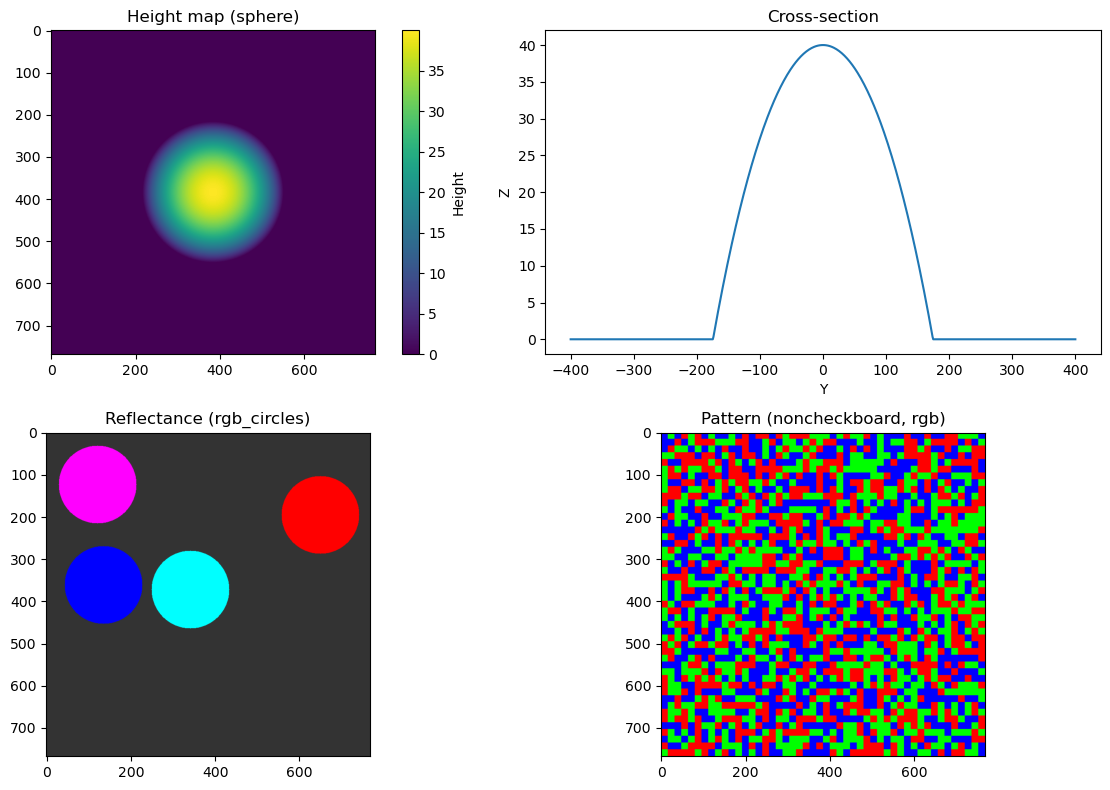

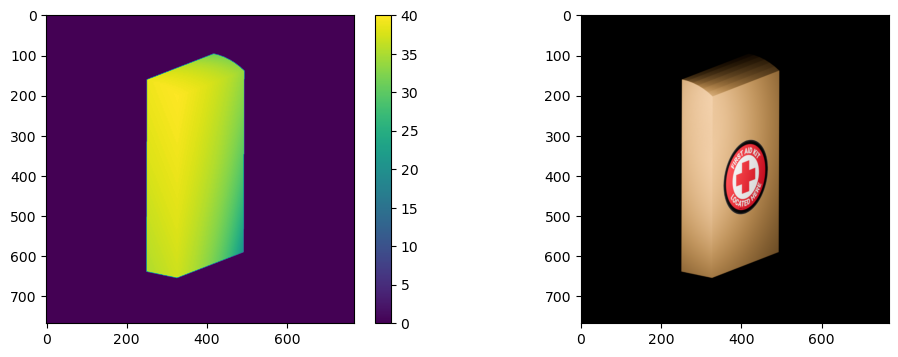

In [3]:
height_map, reflectance, pattern = generate_test_data(pattern_shape, square_size = 16, obj_source="sphere", 
                                                      pattern_source = "noncheckboard" , 
                                                      pattern_mode="rgb",
                                                      reflectance_mode="rgb_circles")
file_path = '../Blender_test/'
relf_path = 'reflectance.png'
heig_path = 'heightmap.png'

# # --- height ---
height_np = cv2.imread(file_path + heig_path, cv2.IMREAD_GRAYSCALE)  # (H,W)
height_np = cv2.resize(height_np, (n_pts, n_pts))
height_np = height_np.astype(np.float32)
height_np = (height_np / (height_np.max() + 1e-12)) * 40.0

height_map = pad_to_size(torch.from_numpy(height_np), (int(pattern_shape*1.5), int(pattern_shape*1.5))).to(torch.float32)

# cv2.resize needs numpy
height_map_np = height_map.cpu().numpy()  # (H,W), float32
height_map_np = cv2.resize(height_map_np, (pattern_shape, pattern_shape), interpolation=cv2.INTER_LINEAR)

# back to torch
height_map = torch.from_numpy(height_map_np).to(torch.float32)
# height_map = height_map.to(device)

# --- reflectance ---
refl_np = cv2.imread(file_path + relf_path)          # (H, W, 3), BGR, uint8
refl_np = cv2.cvtColor(refl_np, cv2.COLOR_BGR2RGB)  # (H, W, 3), RGB
refl_np = cv2.resize(refl_np, (n_pts, n_pts))
refl_np = refl_np.astype(np.float32)

refl_np = refl_np / (refl_np.max() + 1e-12)          # (H, W, 3)

# ========== padding ==========
refl_pad = pad_to_size(
    torch.from_numpy(refl_np),                       # (H, W, 3)
    (int(pattern_shape * 1.5), int(pattern_shape * 1.5))
).numpy()                                            # (H2, W2, 3)

# ========== resize ==========
refl_pad = cv2.resize(
    refl_pad,
    (pattern_shape, pattern_shape),
    interpolation=cv2.INTER_LINEAR
)                                                    # (H, W, 3)

# ========== back to torch, channel-first ==========
reflectance = torch.from_numpy(refl_pad) \
    .permute(2, 0, 1) \
    .to(torch.float32)                               # (3, H, W)


# height_map = torch.rot90(height_map, k = 2,dims = (0,1))/height_map.max()*100
plt.figure(figsize = (12,4))
plt.subplot(121)
plt.imshow(height_map)
plt.colorbar()
plt.subplot(122)
plt.imshow(reflectance.permute(1,2,0))
plt.show()

## if use blender object refletance and height

In [4]:
calib_results = utils.json_loader(file_path=f'../Real_data/{obj}/{obj}_final_calibration_summary.json')
cam_COP = calib_results['camera_position_world']
cam_R = calib_results['R_world_to_camera']
cam_K = calib_results['camera_intrinsic']
proj_COP = calib_results['projector_position_world']
proj_R = calib_results['R_world_to_projector']
proj_K = calib_results['projector_intrinsic']

Projector focal (fx, fy): (2405.9962372020145, 2503.0073079538874)
Projector principal point offset (Δx, Δy): (13.869208331625885, 261.2089887642941)
Camera focal (fx, fy): (4550.583332930169, 4560.969653462267)
Camera principal point offset (Δx, Δy): (62.9898496654705, -70.75718807479461)


<Figure size 1600x800 with 0 Axes>

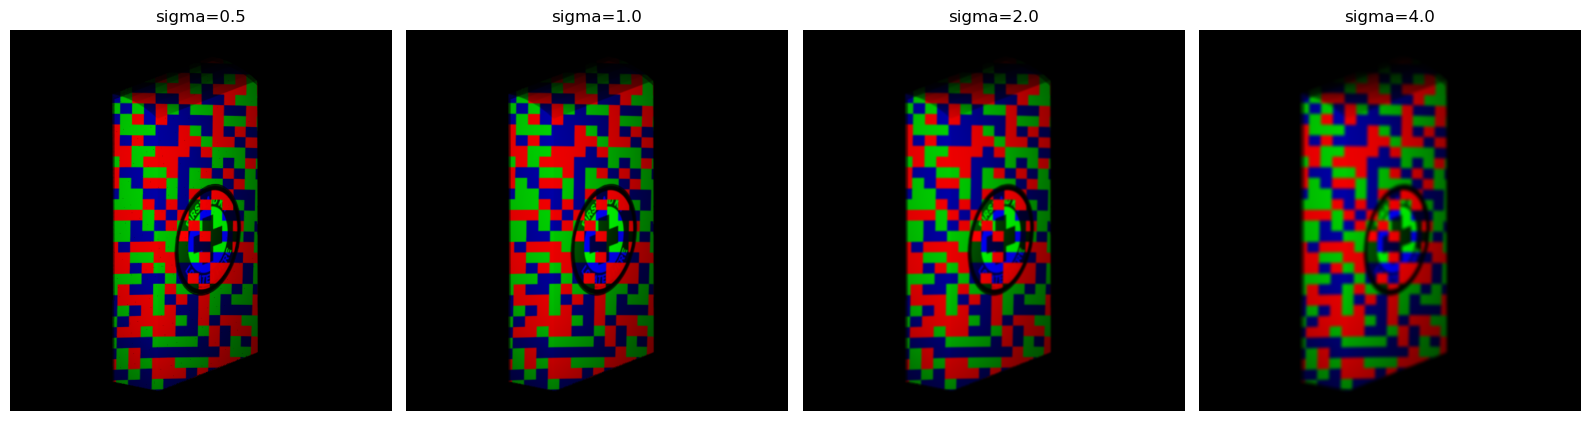

In [5]:
proj_t = -proj_R @ proj_COP
cam_t = -cam_R @ cam_COP


cam_res = (n_pts, n_pts)   
proj_res = (pattern_shape, pattern_shape)  

intrinsics_para = parse_intrinsics(cam_K, proj_K, cam_res, proj_res)

print("Projector focal (fx, fy):", intrinsics_para["projector"]["focal"])
print("Projector principal point offset (Δx, Δy):", intrinsics_para["projector"]["offset"])
print("Camera focal (fx, fy):", intrinsics_para["camera"]["focal"])
print("Camera principal point offset (Δx, Δy):", intrinsics_para["camera"]["offset"])


proj_sensor_size = min(proj_res)
proj_fx, proj_fy = intrinsics_para["projector"]["focal"]   # (fx, fy)
proj_cx_px, proj_cy_px = intrinsics_para["projector"]["offset"]

cam_sensor_size = min(cam_res)
cam_fx,  cam_fy  = intrinsics_para["camera"]["focal"]      # (fx, fy)
cam_cx_px, cam_cy_px = intrinsics_para["camera"]["offset"]
     
    
extent_mm = [-200, 200, -200, 200]   

# Plane coefficients
A = 0.014215
B = 0.008262
C =  0.999865
D = 0.949929

# Extent in mm
xmin, xmax, ymin, ymax = extent_mm

# Resolution
num = proj_res  # 

# Create meshgrid (PyTorch)
x = torch.linspace(xmin, xmax, num[0])
y = torch.linspace(ymin, ymax, num[1])

X, Y = torch.meshgrid(x, y, indexing="xy")  

# Compute Z(x,y)
height_map_whiteboard = -(A * X + B * Y + D) / C

# cam_resolution = 3036
cam_resolution = n_pts
num_photons = None

measured_img = torch.zeros((pattern.shape[0], n_pts, n_pts))[None,:,:,:].to(DEVICE)
imager2 = Proj_Cam_model_ablation(
    proj_f=(proj_fx, proj_fy),
    cam_f=(cam_fx, cam_fy),

    proj_sensor_w_px=proj_sensor_size,
    proj_sensor_h_px=proj_sensor_size,
    cam_sensor_px=cam_sensor_size,

    proj_R=proj_R, proj_t=proj_t,
    cam_R=cam_R, cam_t=cam_t,

    proj_cx_px=proj_cx_px ,
    proj_cy_px=proj_cy_px ,
    cam_cx_px=cam_cx_px,
    cam_cy_px=cam_cy_px,

    device=DEVICE
)

s_range = np.array([0.5, 1,2,4])
plt.figure(figsize = (16,8))

fig, axes = plt.subplots(1, len(s_range), figsize=(16, 8))

if len(s_range) == 1:
    axes = [axes]

for idx, s1 in enumerate(s_range):

    for pattern_c in range(pattern.shape[0]):
        pattern_proj = pattern[pattern_c,:,:]
        measured_img2 = imager2.render(
            height_map,
            reflectance[pattern_c,:,:],
            pattern_proj,
            extent_mm=extent_mm,
            photon_count=num_photons,
            show=0,
            print_matrix=0,
            cam_res=(cam_resolution, cam_resolution), 
            use_soft_z_buffer=1,
            hard_mode='zbuffer',
            sigma_softz=s1,
            radius_multi_softz = 2,
            steepness_softz=200
        )

        measured_img[0, pattern_c, :, :] = measured_img2.squeeze()

    axes[idx].imshow(
        measured_img.squeeze().permute(1,2,0).cpu(),
        origin='lower'
    )
    axes[idx].set_title(f"sigma={s1}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Projector focal (fx, fy): (2405.9962372020145, 2503.0073079538874)
Projector principal point offset (Δx, Δy): (13.869208331625885, 261.2089887642941)
Camera focal (fx, fy): (4550.583332930169, 4560.969653462267)
Camera principal point offset (Δx, Δy): (62.9898496654705, -70.75718807479461)


<Figure size 1600x800 with 0 Axes>

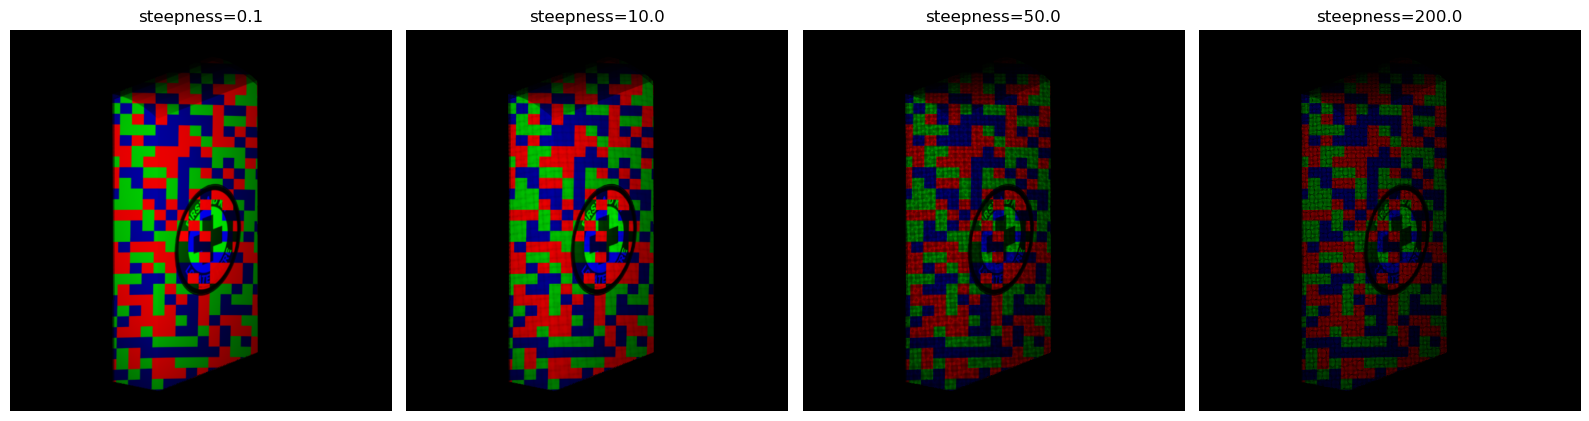

In [6]:
proj_t = -proj_R @ proj_COP
cam_t = -cam_R @ cam_COP


cam_res = (n_pts, n_pts)   
proj_res = (pattern_shape, pattern_shape)  

intrinsics_para = parse_intrinsics(cam_K, proj_K, cam_res, proj_res)

print("Projector focal (fx, fy):", intrinsics_para["projector"]["focal"])
print("Projector principal point offset (Δx, Δy):", intrinsics_para["projector"]["offset"])
print("Camera focal (fx, fy):", intrinsics_para["camera"]["focal"])
print("Camera principal point offset (Δx, Δy):", intrinsics_para["camera"]["offset"])


proj_sensor_size = min(proj_res)
proj_fx, proj_fy = intrinsics_para["projector"]["focal"]   # (fx, fy)
proj_cx_px, proj_cy_px = intrinsics_para["projector"]["offset"]

cam_sensor_size = min(cam_res)
cam_fx,  cam_fy  = intrinsics_para["camera"]["focal"]      # (fx, fy)
cam_cx_px, cam_cy_px = intrinsics_para["camera"]["offset"]
     
    
extent_mm = [-200, 200, -200, 200]   

# Plane coefficients
A = 0.014215
B = 0.008262
C =  0.999865
D = 0.949929

# Extent in mm
xmin, xmax, ymin, ymax = extent_mm

# Resolution
num = proj_res  # 

# Create meshgrid (PyTorch)
x = torch.linspace(xmin, xmax, num[0])
y = torch.linspace(ymin, ymax, num[1])

X, Y = torch.meshgrid(x, y, indexing="xy")  

# Compute Z(x,y)
height_map_whiteboard = -(A * X + B * Y + D) / C

# cam_resolution = 3036
cam_resolution = n_pts
num_photons = None

measured_img = torch.zeros((pattern.shape[0], n_pts, n_pts))[None,:,:,:].to(DEVICE)
imager2 = Proj_Cam_model_ablation(
    proj_f=(proj_fx, proj_fy),
    cam_f=(cam_fx, cam_fy),

    proj_sensor_w_px=proj_sensor_size,
    proj_sensor_h_px=proj_sensor_size,
    cam_sensor_px=cam_sensor_size,

    proj_R=proj_R, proj_t=proj_t,
    cam_R=cam_R, cam_t=cam_t,

    proj_cx_px=proj_cx_px ,
    proj_cy_px=proj_cy_px ,
    cam_cx_px=cam_cx_px,
    cam_cy_px=cam_cy_px,

    device=DEVICE
)

s_range = np.array([0.1, 10,50,200])
plt.figure(figsize = (16,8))

fig, axes = plt.subplots(1, len(s_range), figsize=(16, 8))

if len(s_range) == 1:
    axes = [axes]

for idx, s1 in enumerate(s_range):

    for pattern_c in range(pattern.shape[0]):
        pattern_proj = pattern[pattern_c,:,:]
        measured_img2 = imager2.render(
            height_map,
            reflectance[pattern_c,:,:],
            pattern_proj,
            extent_mm=extent_mm,
            photon_count=num_photons,
            show=0,
            print_matrix=0,
            cam_res=(cam_resolution, cam_resolution), 
            use_soft_z_buffer=1,
            hard_mode='zbuffer',
            sigma_softz=0.5,
            radius_multi_softz = 1,
            steepness_softz=s1
        )

        measured_img[0, pattern_c, :, :] = measured_img2.squeeze()

    axes[idx].imshow(
        measured_img.squeeze().permute(1,2,0).cpu(),
        origin='lower'
    )
    axes[idx].set_title(f"steepness={s1}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
